# W3D1 — Trees & Ensembles — Lab

**Week 3 · Deep Learning & Neural Networks** · Lab

This is the deep-learning week, and it opens with a model that has no neurons in it. That is
deliberate. Before you spend three days building a network by hand, you need a number the network
has to beat — and on a table of numbered columns, the number to beat comes from a tree.

Three things today, in order:

- **One tree**, grown too far on purpose, so you watch the training score reach 0.99 while the
  validation score falls. Overfitting, in your own data, with a hyperparameter you can move.
- **A forest**, and then the same forest with its column randomness switched off — because the
  randomness is not a detail of the implementation, it is the mechanism.
- **Boosting**, a small `learning_rate` × `n_estimators` grid, and one table putting all of it next
  to W1D4's logistic regression and next to a model that does nothing.

You leave with `tree_baseline.json`. On Thursday your NumPy network gets measured against it, and on
Sunday you report which one won. If the tree wins — and on this data it will — that is the result.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٣ اليوم ١ — الأشجار والتجميعات

**الأسبوع ٣ · اليوم ١ · التعلّم العميق والشبكات العصبية** · معمل عملي

هذا أسبوع التعلّم العميق، ويبدأ بنموذج لا عصبون فيه، وهذا مقصود. فقبل أن تصرف ثلاثة أيام في بناء
شبكة بيدك تحتاج رقمًا على الشبكة أن تتجاوزه، والرقم الذي يُتجاوَز على جدول أعمدة مرقّمة يأتي من شجرة.

وثلاثة أمور اليوم بالترتيب:

- **شجرة واحدة** تُنمّيها أكثر مما ينبغي عن قصد، فترى نتيجة التدريب تصل إلى ٠٫٩٩ ونتيجة التحقّق
  تهبط. فرط المطابقة في بياناتك أنت، وبمعامل تستطيع تحريكه.
- **غابة عشوائية**، ثم الغابة نفسها بعد إطفاء عشوائية الأعمدة — لأن العشوائية ليست تفصيلًا في
  التنفيذ، بل هي الآلية نفسها.
- **التعزيز الاشتقاقي** وشبكة صغيرة من `learning_rate` × `n_estimators`، وجدول واحد يضع هذا كله
  بجانب الانحدار اللوجستي من الأسبوع الأول اليوم الرابع، وبجانب نموذج لا يفعل شيئًا.

ستخرج بملف `tree_baseline.json`. ويوم الخميس تُقاس شبكتك المكتوبة بـ NumPy عليه، ويوم الأحد تُبلّغ
أيّهما فاز. وإن فازت الشجرة — وستفوز على هذه البيانات — فتلك هي النتيجة.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Fit a depth-1 tree and read the threshold it chose, and say why it is 83.0 and not 80.
- Produce overfitting on purpose by raising `max_depth`, and point at the exact depth where the
  train–validation gap opens.
- Say what a random forest randomises, and show by measurement what happens when one of the two
  sources of randomness is removed.
- Sweep `learning_rate` against `n_estimators` and read the trade-off between them.
- Put five models in one table — dummy, linear, tree, forest, boosting — with a mean **and** a spread
  for each.
- Read a feature-importance chart and name the one thing it proves and the two it does not.
- Show that scaling a tree's features changes nothing, to four decimal places.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- تدريب شجرة بعمق ١ وقراءة العتبة التي اختارتها، وبيان لماذا كانت ٨٣٫٠ لا ٨٠.
- إنتاج فرط المطابقة عن قصد برفع `max_depth`، وتحديد العمق الذي تنفتح عنده الفجوة بين التدريب
  والتحقّق.
- بيان ما تُعشّيه الغابة العشوائية، وإظهار ما يحدث بالقياس عند إزالة أحد مصدري العشوائية.
- تجريب `learning_rate` مقابل `n_estimators` وقراءة المفاضلة بينهما.
- وضع خمسة نماذج في جدول واحد — نموذج ساذج وخطي وشجرة وغابة وتعزيز — لكل منها متوسط **ومدى تفاوت**.
- قراءة مخطّط أهمية الخصائص وتسمية الشيء الوحيد الذي يُثبته والشيئين اللذين لا يُثبتهما.
- إظهار أن تقييس خصائص الشجرة لا يغيّر شيئًا، إلى أربع خانات عشرية.

</div>


## About the data

**Dataset:** `credit_default` — 30,000 rows × 25 columns, UCI *Default of Credit Card Clients*, CC BY 4.0

One row is one credit-card client in Taiwan, over six months. The columns are their credit limit,
their age, their education and marital status, six months of repayment status (`PAY_0` … `PAY_6`), six
months of bill amounts (`BILL_AMT1` … `BILL_AMT6`) and six months of payments (`PAY_AMT1` … `PAY_AMT6`).
The target is `default_next_month`: did this client default on the next payment.

**This is W1D4's dataset, on purpose.** You already have a logistic-regression number on it, and
today's models are measured against that number rather than against nothing.

**The metric is ROC AUC, not accuracy.** 77.9% of these clients did not default, so a model that
predicts "no default" for everybody scores 0.7788 and W1D4 spent a whole lab on why that number is a
trap. AUC asks whether the model ranks a defaulter above a non-defaulter, and a model that does
nothing scores exactly 0.5 on it. You will see both numbers in task 2.4.

**Watch out:** `BILL_AMT1` and `BILL_AMT2` are 0.95 correlated — the same debt, one month apart. Six
of these columns are near-copies of each other, and in task 2.5 that is what breaks the
feature-importance ranking. `ID` is a row number and is not a feature; drop it and never think about
it again.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `credit_default` — ٣٠٬٠٠٠ صفًا × ٢٥ عمودًا، من UCI، رخصة CC BY 4.0

الصف الواحد هو عميل بطاقة ائتمان في تايوان على مدى ستة أشهر. والأعمدة هي حدّ الائتمان والعمر والتعليم
والحالة الاجتماعية، وحالة السداد لستة أشهر (`PAY_0` … `PAY_6`)، ومبالغ الفواتير لستة أشهر
(`BILL_AMT1` … `BILL_AMT6`)، والمدفوعات لستة أشهر (`PAY_AMT1` … `PAY_AMT6`). والهدف هو
`default_next_month`: هل تعثّر هذا العميل في الدفعة التالية.

**وهذه بيانات الأسبوع الأول اليوم الرابع عن قصد.** فلديك رقم انحدار لوجستي عليها أصلًا، ونماذج اليوم
تُقاس على ذلك الرقم لا على لا شيء.

**والمقياس هو المساحة تحت منحنى ROC لا الدقة الكلية.** فـ ٧٧٫٩٪ من هؤلاء العملاء لم يتعثّروا، فنموذج
يقول «لا تعثّر» للجميع يسجّل ٠٫٧٧٨٨، وقد صرف الأسبوع الأول اليوم الرابع معملًا كاملًا في بيان أن هذا
الرقم فخّ. أما المساحة تحت المنحنى فتسأل: هل يرتّب النموذج المتعثّر فوق غير المتعثّر؟ ونموذج لا يفعل
شيئًا يسجّل ٠٫٥ بالضبط. وسترى الرقمين في المهمة ٢٫٤.

**انتبه:** الارتباط بين `BILL_AMT1` و`BILL_AMT2` هو ٠٫٩٥ — الدَّين نفسه بفارق شهر. وستة من هذه الأعمدة
نسخ شبه متطابقة، وهذا بالضبط ما يُفسد ترتيب أهمية الخصائص في المهمة ٢٫٥. أما `ID` فهو رقم صف لا خاصية،
فاحذفه ولا تفكّر فيه بعدها.

</div>


## Setup

Run the cell below first. It loads the data, fixes the feature list, the split and the
cross-validator that every comparison in this notebook shares — so that two numbers in this lab
differ only by the thing being compared.

<div dir="rtl" align="right">

## الإعداد

شغّل الخليّة أدناه أولًا. تُحمّل البيانات وتُثبّت قائمة الخصائص والتقسيم والمُقسِّم المتقاطع الذي
تشترك فيه كل مقارنة في هذا الدفتر، فلا يختلف رقمان هنا إلا بالشيء المُقارَن.

</div>


In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("scikit-learn", "matplotlib", "pyarrow")
seed_everything(42)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

from aiep.viz import use_course_style, PALETTE
use_course_style()

df = pd.read_parquet(get_dataset("credit_default"))

TARGET = "default_next_month"
FEATURES = [c for c in df.columns if c not in ("ID", TARGET)]   # ID is a row number
X = df[FEATURES]
y = df[TARGET]

# One split for the depth curves in task 2.1, one cross-validator for every model
# comparison after it. Same folds every time, so two scores differ only by the model.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "roc_auc"

# W1D4's logistic regression, on three columns, reported accuracy 0.8103 and AUC 0.6971.
W1D4_LOGREG_AUC = 0.6971

print(f"{len(df):,} rows | {len(FEATURES)} features | default rate {y.mean():.2%}")
print(f"train {len(X_train):,} / validation {len(X_val):,}")
print("\n", versions())

📁 credit_default: using cached file at C:\Users\حمزة\AIEP_Olo_student\shared\data_cache\credit_default.parquet
30,000 rows | 23 features | default rate 22.12%
train 24,000 / validation 6,000

 python 3.11.16 | numpy 2.0.2 | pandas 3.0.5 | scikit-learn 1.9.0 | torch 2.13.0+cpu | transformers 5.15.1


## Section 1 — Warm-up: the eight rows from the slide  (≈25 min)

Everything in this section already works.

These are the eight customers from this morning. You found `monthly_charge > 80` by counting labels,
and the room agreed it beat `tenure < 6` because it left one group **pure** — four customers, zero
churners, nothing more to ask.

First, put a number on that. The arithmetic that automates your counting is Gini impurity: `0` for a
pure group, higher for a mixed one. Compute it for both splits and see how far apart they are.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: الصفوف الثمانية من الشريحة (نحو ٢٥ دقيقة)

كل ما في هذا القسم يعمل أصلًا.

هؤلاء العملاء الثمانية من محاضرة الصباح. وجدت `monthly_charge > 80` بعدّ التصنيفات، واتّفقت القاعة
على أنها تتجاوز `tenure < 6` لأنها تركت مجموعة **نقية** — أربعة عملاء وصفر مغادرين ولا سؤال بعدها.

وأولًا: ضَع رقمًا على ذلك. فالحساب الذي يُؤتمِت عدّك هو شوائب Gini: صفر للمجموعة النقية، وأكبر
للمختلطة. احسبها للتقسيمين وانظر كم يبتعدان.

</div>


In [2]:
eight = pd.DataFrame({
    "customer":       ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"],
    "tenure":         [   2,    3,    4,    8,   14,   22,   30,   36],
    "monthly_charge": [  95,   88,   42,   91,   55,   78,   45,   92],
    "churned":        [   1,    1,    0,    1,    0,    0,    0,    0],
})
X8 = eight[["tenure", "monthly_charge"]]
y8 = eight["churned"]


def gini(labels):
    """1 - sum of squared class shares. Zero for a pure group."""
    labels = np.asarray(labels)
    if len(labels) == 0:
        return 0.0
    p = labels.mean()
    return 1 - (p ** 2 + (1 - p) ** 2)


def split_gini(mask):
    """Gini of the two groups a boolean mask makes, weighted by their sizes."""
    left, right = y8[mask], y8[~mask]
    return (len(left) * gini(left) + len(right) * gini(right)) / len(y8)


print(f"the whole table:            {gini(y8):.4f}   (3 churners of 8)")
print(f"split A  tenure < 6:        {split_gini(eight['tenure'] < 6):.4f}   (2-of-3 and 1-of-5)")
print(f"split B  monthly_charge>80: {split_gini(eight['monthly_charge'] > 80):.4f}   (3-of-4 and 0-of-4)")

the whole table:            0.4688   (3 churners of 8)
split A  tenure < 6:        0.3667   (2-of-3 and 1-of-5)
split B  monthly_charge>80: 0.1875   (3-of-4 and 0-of-4)


### Task 1.1 — the tree agrees with you, and picks a different column

Split B scores 0.1875 against split A's 0.3667, which is the room's answer with a number attached.

Now let the library choose, and read what it printed rather than what you expected.

<div dir="rtl" align="right">

### المهمة ١٫١ — الشجرة توافقك، وتختار عمودًا آخر

سجّل التقسيم B قيمة ٠٫١٨٧٥ مقابل ٠٫٣٦٦٧ للتقسيم A، وهذا هو جواب القاعة ومعه رقم.

ودَع المكتبة تختار الآن، واقرأ ما طبعته لا ما توقّعته.

</div>


In [3]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X8, y8)
print(export_text(stump, feature_names=["tenure", "monthly_charge"]))

CHOSEN_FEATURE = ["tenure", "monthly_charge"][stump.tree_.feature[0]]
CHOSEN_THRESHOLD = stump.tree_.threshold[0]
CHOSEN_GINI = split_gini(eight[CHOSEN_FEATURE] <= CHOSEN_THRESHOLD)

print(f"the tree split on {CHOSEN_FEATURE} <= {CHOSEN_THRESHOLD:.2f}")
print(f"its weighted Gini:      {CHOSEN_GINI:.4f}")
print(f"the room's split B:     {split_gini(eight['monthly_charge'] > 80):.4f}")
print(f"the same number: {np.isclose(CHOSEN_GINI, split_gini(eight['monthly_charge'] > 80))}")
print(f"\ntenure < 11 puts C1, C2, C3, C4 on the left — labels "
      f"{list(y8[eight['tenure'] < 11])} — and C5..C8 on the right, all zeros.")

|--- tenure <= 11.00
|   |--- class: 1
|--- tenure >  11.00
|   |--- class: 0

the tree split on tenure <= 11.00
its weighted Gini:      0.1875
the room's split B:     0.1875
the same number: True

tenure < 11 puts C1, C2, C3, C4 on the left — labels [1, 1, 0, 1] — and C5..C8 on the right, all zeros.


Read that carefully, because it is the first honest surprise of the week.

The tree did **not** pick your column. It split on `tenure <= 11`, which puts C1, C2, C3, C4 on one
side (labels 1, 1, 0, 1) and C5 to C8 on the other (0, 0, 0, 0). Three-of-four, and a pure group of
four — **exactly the same shape as your split B**, and exactly the same weighted Gini: 0.1875.

The two splits are tied. They cut the eight rows into the same two groups, using different columns,
and no counting rule can separate them. So the tree broke the tie the way it breaks every tie: by
the order it happened to consider the columns in.

This is slide 62 arriving four hours early. When a chart later tells you `tenure` mattered and
`monthly_charge` did not, this is the mechanism behind that claim — and now you have watched it
happen on eight rows you can hold in your head.

<div dir="rtl" align="right">

اقرأ ذلك بتمعّن، فهو أول مفاجأة صادقة في الأسبوع.

الشجرة **لم** تختر عمودك. قسّمت على `tenure <= 11`، وهذا يضع C1 وC2 وC3 وC4 في جهة (تصنيفاتها ١، ١،
٠، ١) وC5 إلى C8 في الجهة الأخرى (٠، ٠، ٠، ٠). ثلاثة من أربعة، ومجموعة نقية من أربعة — **الشكل نفسه
تمامًا لتقسيمك B**، وقيمة Gini الموزونة نفسها: ٠٫١٨٧٥.

فالتقسيمان متعادلان. يقطعان الصفوف الثمانية إلى المجموعتين نفسهما بعمودين مختلفين، ولا قاعدة عدّ
تفصل بينهما. فكسرت الشجرة التعادل كما تكسر كل تعادل: بالترتيب الذي صادف أن نظرت به في الأعمدة.

وهذه هي الشريحة ٦٢ وقد وصلت قبل موعدها بأربع ساعات. فحين يقول لك مخطّط لاحقًا إن `tenure` مهمّ
و`monthly_charge` غير مهمّ، فهذه هي الآلية وراء ذلك الادعاء — وقد رأيتها الآن تحدث على ثمانية صفوف
تحتفظ بها في رأسك.

</div>


### Task 1.2 — and where the slide's 83.00 came from

Give the tree one column only — the one the room chose — and it prints the threshold from slide 27.

Nothing in the data is 83. A tree only ever compares values it has actually seen, and between 78
(C6) and 88 (C2) there is no observed charge at all, so it puts the boundary halfway:
`(78 + 88) / 2 = 83.0`. Any number in that gap produces an identical partition, and therefore an
identical tree.

Your 80 and its 83 are **the same split**. Expect this every time you read a threshold off
`plot_tree`, and do not go looking for meaning in the exact number.

<div dir="rtl" align="right">

### المهمة ١٫٢ — ومن أين جاءت الـ ٨٣٫٠٠ في الشريحة

أعطِ الشجرة عمودًا واحدًا فقط — الذي اختارته القاعة — فتطبع العتبة الموجودة في الشريحة ٢٧.

ولا شيء في البيانات يساوي ٨٣. فالشجرة لا تقارن إلا قيمًا رأتها فعلًا، وبين ٧٨ (C6) و٨٨ (C2) لا توجد
أي قيمة مرصودة، فتضع الحدّ في المنتصف: `(78 + 88) / 2 = 83.0`. وأي رقم في هذه الفجوة يُنتج التقسيم
نفسه، ومن ثمّ الشجرة نفسها.

فالثمانون التي كتبتها والثلاثة والثمانون التي كتبتها الشجرة هما **التقسيم نفسه**. توقّع هذا كل مرة
تقرأ فيها عتبة من `plot_tree`، ولا تبحث عن معنى في الرقم بالضبط.

</div>


|--- monthly_charge <= 83.00
|   |--- class: 0
|--- monthly_charge >  83.00
|   |--- class: 1

threshold: 83.00
observed charges: [42, 45, 55, 78, 88, 91, 92, 95]
midpoint of 78 and 88: 83.0

depth-2 training accuracy: 1.00 (8/8)


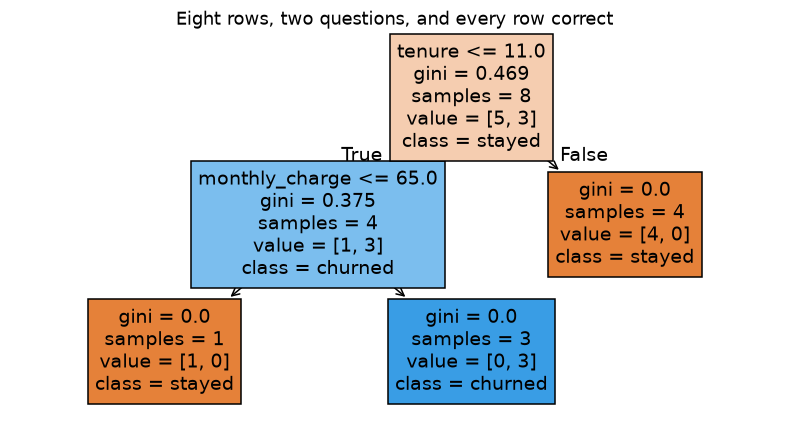


inside the high-charge group (C1, C2, C4, C8), tenures [2, 3, 8, 36], labels [1, 1, 1, 0]
|--- tenure <= 22.00
|   |--- class: 1
|--- tenure >  22.00
|   |--- class: 0

one row — C8 — is alone on the far side of that split, and it decides everything above tenure 22


In [4]:
charge_only = DecisionTreeClassifier(max_depth=1, random_state=42).fit(
    eight[["monthly_charge"]], y8)
print(export_text(charge_only, feature_names=["monthly_charge"]))

CHARGE_THRESHOLD = charge_only.tree_.threshold[0]
neighbours = sorted(eight["monthly_charge"])
print(f"threshold: {CHARGE_THRESHOLD:.2f}")
print(f"observed charges: {neighbours}")
print(f"midpoint of 78 and 88: {(78 + 88) / 2}")

full8 = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X8, y8)
print(f"\ndepth-2 training accuracy: {full8.score(X8, y8):.2f} "
      f"({int(full8.score(X8, y8) * 8)}/8)")

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_tree(full8, feature_names=["tenure", "monthly_charge"],
          class_names=["stayed", "churned"], filled=True, ax=ax)
ax.set_title("Eight rows, two questions, and every row correct")
plt.show()

# The room's own tree, followed by hand: inside the high-charge group, which
# tenure separates the one non-churner?
high_charge = eight[eight["monthly_charge"] > 83]
inner = DecisionTreeClassifier(max_depth=1, random_state=42).fit(
    high_charge[["tenure"]], high_charge["churned"])
print(f"\ninside the high-charge group (C1, C2, C4, C8), tenures "
      f"{list(high_charge['tenure'])}, labels {list(high_charge['churned'])}")
print(export_text(inner, feature_names=["tenure"]))
print(f"one row — C8 — is alone on the far side of that split, and it decides "
      f"everything above tenure {inner.tree_.threshold[0]:.0f}")

The room's tree, followed by hand, ends where the lecture said it would: the high-charge group splits
at `tenure <= 22` (the midpoint of 8 and 36, by the same gap rule), and **one** training row — C8 —
sits alone on the far side. The ninth customer from activity 3, tenure 34 and charge 96, lands in
that leaf, and its prediction of *not churn* rests on that single client.

Nothing on the chart says so unless you read `samples = 1`. That is Section 2's first task, on eight
rows instead of thirty thousand.

<div dir="rtl" align="right">

شجرة القاعة، متتبَّعةً باليد، تنتهي حيث قالت المحاضرة: تنقسم مجموعة الفاتورة المرتفعة عند
`tenure <= 22` (منتصف ٨ و٣٦ بقاعدة الفجوة نفسها)، ويجلس صفّ تدريب **واحد** — هو C8 — وحده في الجهة
البعيدة. والعميل التاسع من النشاط الثالث، بأقدمية ٣٤ وفاتورة ٩٦، يقع في تلك الورقة، ويستند تنبّؤه
بـ«لا مغادرة» إلى ذلك العميل الواحد.

ولا شيء في الرسم يقول ذلك إلا إذا قرأت `samples = 1`. وهذه هي المهمة الأولى من القسم الثاني، على
ثمانية صفوف بدلًا من ثلاثين ألفًا.

</div>


## Section 2 — Core: six tasks  (≈60 min)

1. Grow one tree at five depths and plot the train–validation gap opening.
2. A random forest, then the same forest with its column randomness removed.
3. Boosting: `learning_rate` × `n_estimators`, cross-validated.
4. One table: dummy, logistic regression, best tree, forest, boosting.
5. Feature importance, and the pair of columns that breaks the ranking.
6. Scale every feature and confirm the forest's score does not move.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: ست مهام (نحو ٦٠ دقيقة)

١. نمِّ شجرة واحدة على خمسة أعماق وارسم انفتاح الفجوة بين التدريب والتحقّق.
٢. غابة عشوائية، ثم الغابة نفسها بعد إزالة عشوائية الأعمدة.
٣. التعزيز: `learning_rate` × `n_estimators` بتحقّق متقاطع.
٤. جدول واحد: نموذج ساذج، وانحدار لوجستي، وأفضل شجرة، وغابة، وتعزيز.
٥. أهمية الخصائص، وزوج الأعمدة الذي يُفسد الترتيب.
٦. قيِّس كل خاصية وتحقّق أن نتيجة الغابة لا تتحرّك.

</div>


### Task 2.1 — grow it until it breaks

`max_depth` is how many questions the tree may ask in a row, and it is the only thing you change
here. Fit at depth 1, 3, 5, 10 and `None` (unlimited), and record **both** scores each time: on the
rows it was fitted on, and on the 6,000 rows it has never seen.

The training curve only goes up. The validation curve peaks and then comes back down. The distance
between them is the definition of overfitting you have been using since W2D5 — and this is the first
time you produce it on purpose.

Use accuracy here, not AUC: an unpruned tree predicts hard labels, and "0.9995 of the training rows
correct" is the number that makes the point.

<div dir="rtl" align="right">

### المهمة ٢٫١ — نمِّها حتى تنكسر

`max_depth` هو عدد الأسئلة التي تسألها الشجرة على التوالي، وهو الشيء الوحيد الذي تغيّره هنا. درّب
على الأعماق ١ و٣ و٥ و١٠ و`None` (بلا حدّ)، وسجّل **النتيجتين** كل مرة: على الصفوف التي تدرّبت عليها،
وعلى الستة آلاف صف التي لم ترها قط.

منحنى التدريب يصعد فقط. ومنحنى التحقّق يبلغ قمّته ثم يهبط. والمسافة بينهما هي تعريف فرط المطابقة الذي
تستخدمه من الأسبوع الثاني اليوم الخامس — وهذه أول مرة تُنتجه عن قصد.

استخدم الدقة الكلية هنا لا المساحة تحت المنحنى: فالشجرة غير المُقلَّمة تتنبّأ بتصنيفات نهائية، و«٠٫٩٩٩٥
من صفوف التدريب صائبة» هو الرقم الذي يوصل الفكرة.

</div>


In [5]:
# ────────────────────────────────────────────────────────────────────
# 1) Loop over the five depths. Fit a DecisionTreeClassifier on the training
#    rows at each one, with random_state=42 so your numbers match your neighbour's.
# 2) Record the accuracy on the training rows and on the validation rows in the
#    same loop — you need the pair, not two separate sweeps.
# 3) Build a DataFrame with a depth column and both scores, and add a "gap" column.
# Search: "sklearn DecisionTreeClassifier max_depth score"
# https://scikit-learn.org/stable/modules/tree.html
#
# ١) كرّر على الأعماق الخمسة. درّب `DecisionTreeClassifier` على صفوف التدريب عند
#    كل عمق، مع `random_state=42` لتطابق أرقامك أرقام جارك.
# ٢) سجّل الدقة على صفوف التدريب وعلى صفوف التحقّق في الحلقة نفسها — أنت تحتاج
#    الزوج لا تجريبين منفصلين.
# ٣) ابنِ `DataFrame` فيه عمود العمق والنتيجتان، وأضِف عمود «الفجوة».
# ابحث عن: "sklearn DecisionTreeClassifier max_depth score"
# ────────────────────────────────────────────────────────────────────

DEPTHS = [1, 3, 5, 10, None]
# TODO: Fit a tree at each depth and record train and validation accuracy.
# مهمة: درّب شجرة عند كل عمق وسجّل دقة التدريب ودقة التحقّق.

depth_records = []
for depth in DEPTHS:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_score = tree.score(X_train, y_train)
    val_score = tree.score(X_val, y_val)
    depth_records.append({
        "depth": depth,
        "train": train_score,
        "val": val_score,
        "gap": train_score - val_score,
        "leaves": tree.tree_.n_leaves,
    })

depth_curve = pd.DataFrame(depth_records)
print(depth_curve.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

  depth  train    val    gap  leaves
 1.0000 0.8197 0.8192 0.0005       2
 3.0000 0.8231 0.8187 0.0045       8
 5.0000 0.8252 0.8172 0.0080      31
10.0000 0.8446 0.8107 0.0340     306
    NaN 0.9995 0.7145 0.2850    3791


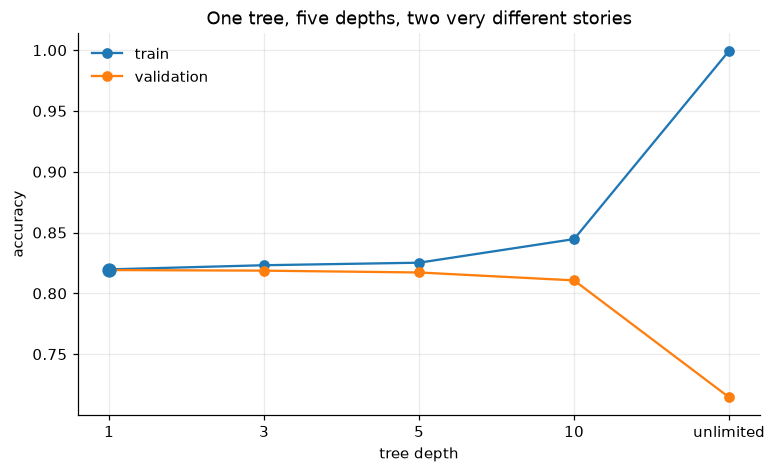

unlimited depth: train 0.9995, validation 0.7145, gap 0.2850, 3,791 leaves


In [8]:
# ────────────────────────────────────────────────────────────────────
# 1) One figure, two lines: training accuracy and validation accuracy against depth.
# 2) Mark the depth where validation peaks — that is the model you would ship.
# 3) Label the axes and add a legend. A chart nobody can read is not evidence.
# Search: "matplotlib plot two lines legend annotate"
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
#
# ١) شكل واحد وخطّان: دقة التدريب ودقة التحقّق مقابل العمق.
# ٢) أشِر إلى العمق الذي تبلغ عنده نتيجة التحقّق قمّتها — فهو النموذج الذي ستُصدره.
# ٣) سمِّ المحورين وأضِف مفتاحًا للرسم. فالمخطّط غير المقروء ليس دليلًا.
# ابحث عن: "matplotlib plot two lines legend annotate"
# ────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4.5))
# TODO: Plot both curves against depth_curve["depth"], then mark the validation peak.
# مهمة: ارسم المنحنيين مقابل `depth_curve["depth"]`، ثم أشِر إلى قمّة التحقّق.

depth_curve["depth"] = depth_curve["depth"].astype(object).where(
    depth_curve["depth"].notna(), None
)

depth_x = depth_curve["depth"].map(
    lambda value: "unlimited" if value is None else str(int(value))
)
ax.plot(depth_x, depth_curve["train"], marker="o", label="train")
ax.plot(depth_x, depth_curve["val"], marker="o", label="validation")
peak_idx = depth_curve["val"].idxmax()
ax.scatter(
    depth_x.loc[peak_idx],
    depth_curve.loc[peak_idx, "val"],
    s=70,
    zorder=3,
)
ax.set_xlabel("tree depth")
ax.set_ylabel("accuracy")
ax.set_title("One tree, five depths, two very different stories")
ax.legend()
plt.show()
print(f"unlimited depth: train {depth_curve.iloc[-1]['train']:.4f}, "
      f"validation {depth_curve.iloc[-1]['val']:.4f}, "
      f"gap {depth_curve.iloc[-1]['gap']:.4f}, "
      f"{int(depth_curve.iloc[-1]['leaves']):,} leaves")

Read the last line before you go on.

The unlimited tree gets **0.9995** of the training rows right and **0.7177** of the validation rows —
a gap of 0.28 — and it does it with 3,782 leaves. Many of those leaves hold a single client. It
is C8's leaf from the warm-up, thousands of times over: a register of clients, rewritten as
questions.

And notice where the best validation accuracy is: `max_depth=1`. A single question about `PAY_0`
beats every deeper tree on this data. That is not a mistake in your code — it is what the accuracy
metric looks like on a dataset that is 78% one class, and it is exactly why the rest of this lab is
measured with AUC.

<div dir="rtl" align="right">

اقرأ السطر الأخير قبل أن تكمل.

الشجرة بلا حدّ تُصيب **٠٫٩٩٩٥** من صفوف التدريب و**٠٫٧١٧٧** من صفوف التحقّق — فجوة ٠٫٢٨ — وتفعل ذلك
بـ ٣٬٧٨٢ ورقة. وكثير من هذه الأوراق يحمل عميلًا واحدًا. إنها ورقة C8 من التهيئة، مكرّرة آلاف
المرات: سجلّ عملاء مكتوب على هيئة أسئلة.

ولاحظ أين تكون أفضل دقة تحقّق: عند `max_depth=1`. سؤال واحد عن `PAY_0` يتجاوز كل شجرة أعمق على هذه
البيانات. وهذا ليس خطأً في شيفرتك، بل هو شكل مقياس الدقة الكلية على بيانات ٧٨٪ منها فئة واحدة، وهو
بالضبط سبب قياس بقية هذا المعمل بالمساحة تحت المنحنى.

</div>


### Task 2.2 — the forest, and then the forest with the randomness taken out

A forest randomises **two** things: the rows each tree sees (a bootstrap sample, drawn with
replacement) and the columns each tree may consider at each split. Take the second one away —
`max_features=1.0` lets every tree look at all 23 columns — and every tree finds the same dominant
column first, and the committee becomes one member with more meetings.

Three cross-validated numbers here, on the same folds: the best single tree, the forest, and the
forest with all columns. Watch the mean **and** the spread.

This one takes about half a minute. `n_jobs=-1` uses every core you have.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — الغابة، ثم الغابة بعد إزالة العشوائية

الغابة تُعشّي **شيئين**: الصفوف التي تراها كل شجرة (عيّنة تمهيدية مسحوبة بالإرجاع)، والأعمدة التي
يُسمح لكل شجرة بالنظر فيها عند كل تقسيم. فأزِل الثاني — إذ يجعل `max_features=1.0` كل شجرة تنظر في
الأعمدة الثلاثة والعشرين كلها — فتجد كل شجرة العمود المهيمن نفسه أولًا، وتصبح اللجنة عضوًا واحدًا
باجتماعات أكثر.

وثلاثة أرقام هنا بتحقّق متقاطع على الطيّات نفسها: أفضل شجرة واحدة، والغابة، والغابة بكل الأعمدة.
راقب المتوسط **ومدى التفاوت**.

تستغرق هذه نحو نصف دقيقة، و`n_jobs=-1` يستخدم كل نواة عندك.

</div>


In [10]:
# ────────────────────────────────────────────────────────────────────
# 1) You need AUC now, not accuracy. cross_val_score takes a scoring argument
#    and CV is already defined for you in the setup cell — use both.
# 2) Score three estimators on the same folds: a tree at the depth that scored
#    best on AUC (try 5), a RandomForestClassifier with 200 trees, and the same
#    forest with max_features=1.0.
# 3) Report each as a mean and a standard deviation. The spread is half the lesson.
# Search: "sklearn RandomForestClassifier max_features cross_val_score roc_auc"
# https://scikit-learn.org/stable/modules/ensemble.html#random-forests
#
# ١) أنت تحتاج المساحة تحت المنحنى الآن لا الدقة الكلية. يأخذ `cross_val_score`
#    وسيط `scoring`، و`CV` مُعرَّف لك في خليّة الإعداد — استخدم الاثنين.
# ٢) قِس ثلاثة مُقدِّرات على الطيّات نفسها: شجرة عند العمق الأفضل على المساحة تحت
#    المنحنى (جرّب ٥)، و`RandomForestClassifier` بمئتي شجرة، والغابة نفسها
#    بـ `max_features=1.0`.
# ٣) اعرض كل واحد بمتوسط وانحراف معياري. فمدى التفاوت نصف الدرس.
# ابحث عن: "sklearn RandomForestClassifier max_features cross_val_score roc_auc"
# ────────────────────────────────────────────────────────────────────

def cv_auc(estimator, label):
    """Five folds, the shared splitter, AUC. Prints and returns the five scores."""
    scores = cross_val_score(estimator, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    print(f"{label:34} {scores.mean():.4f} +/- {scores.std():.4f}")
    return scores
# TODO: Score a single tree at max_depth=5 with cv_auc.
# مهمة: قِس شجرة واحدة عند `max_depth=5` بـ `cv_auc`.

tree_scores = cv_auc(
    DecisionTreeClassifier(max_depth=5, random_state=42),
    "single tree (max_depth=5)",
)
# TODO: Score a 200-tree random forest, leaving max_features at its default.
# مهمة: قِس غابة عشوائية بمئتي شجرة مع ترك `max_features` على قيمته الافتراضية.

forest_scores = cv_auc(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
    "random forest (200 trees)",
)
# TODO: Score the same forest with max_features=1.0 — every tree sees every column.
# مهمة: قِس الغابة نفسها بـ `max_features=1.0` — فترى كل شجرة كل عمود.

no_column_randomness = cv_auc(
    RandomForestClassifier(
        n_estimators=200,
        max_features=1.0,
        random_state=42,
        n_jobs=1,
    ),
    "forest (max_features=1.0)",
)
print(f"\nthe column randomness is worth "
      f"{forest_scores.mean() - no_column_randomness.mean():+.4f} of AUC")
print(f"and it halves the spread: {no_column_randomness.std():.4f} "
      f"-> {forest_scores.std():.4f}")

single tree (max_depth=5)          0.7548 +/- 0.0072
random forest (200 trees)          0.7655 +/- 0.0037
forest (max_features=1.0)          0.7608 +/- 0.0073

the column randomness is worth +0.0048 of AUC
and it halves the spread: 0.0073 -> 0.0037


Two things happened, and the second matters more than the first.

**The mean went up** by 0.005 — real, and small enough that someone could argue about it.

**The spread halved**, from 0.0074 to 0.0036. Same data, same folds, same number of trees; the only
difference is whether the trees were allowed to disagree. A forest whose members all consider all 23
columns finds the same first split every time, so its five fold-scores swing twice as far. That is
the answer to activity 5, measured: without the randomness you have one tree, repeated, and you pay
for two hundred of them.

<div dir="rtl" align="right">

حدث شيئان، والثاني أهمّ من الأول.

**ارتفع المتوسط** بمقدار ٠٫٠٠٥ — فرق حقيقي، وصغير بما يكفي ليجادل فيه أحد.

**وانخفض مدى التفاوت إلى النصف**، من ٠٫٠٠٧٤ إلى ٠٫٠٠٣٦. البيانات نفسها والطيّات نفسها وعدد الأشجار
نفسه؛ والفرق الوحيد هو هل سُمح للأشجار أن تختلف. فالغابة التي تنظر كل أشجارها في الأعمدة الثلاثة
والعشرين كلها تجد التقسيم الأول نفسه كل مرة، فتتأرجح نتائج طيّاتها الخمس ضعف ما تتأرجح. وهذا هو جواب
النشاط الخامس مقيسًا: بلا العشوائية عندك شجرة واحدة مكرّرة، وتدفع ثمن مئتين منها.

</div>


### Task 2.3 — boosting, and the two knobs that trade against each other

Boosting is the other arrangement: each new tree is trained on what the previous ones got wrong, and
their predictions are **summed** rather than voted on. `learning_rate` is how much of each
correction is actually applied; `n_estimators` is how many corrections you make. Halve the rate and
you need roughly twice the trees.

Sweep the grid below — six configurations, five folds each. This is the slowest cell in the lab, at
about a minute and a half. While it runs, write down which of the six you expect to win.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — التعزيز، والمقبضان اللذان يتبادلان

التعزيز ترتيب آخر: كل شجرة جديدة تتدرّب على ما أخطأت فيه السابقات، وتُجمَع تنبّؤاتها **جمعًا** لا
تصويتًا. و`learning_rate` هو مقدار ما يُطبَّق فعلًا من كل تصحيح، و`n_estimators` هو عدد التصحيحات.
فإن نصّفت المعدّل احتجت نحو ضعف الأشجار.

جرِّب الشبكة أدناه — ستة إعدادات، خمس طيّات لكل منها. وهذه أبطأ خليّة في المعمل، نحو دقيقة ونصف.
وبينما تعمل، اكتب أيّ الستة تتوقّع فوزه.

</div>


In [11]:
# ────────────────────────────────────────────────────────────────────
# 1) Two nested loops over the rates and the tree counts, or itertools.product.
# 2) At each combination, build a GradientBoostingClassifier with random_state=42
#    and score it with cv_auc from the previous task.
# 3) Collect the rate, the count, the mean and the std into a DataFrame and sort
#    it by the mean so the winner is the first row.
# Search: "sklearn GradientBoostingClassifier learning_rate n_estimators"
# https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting
#
# ١) حلقتان متداخلتان على المعدّلات وأعداد الأشجار، أو `itertools.product`.
# ٢) عند كل تركيبة ابنِ `GradientBoostingClassifier` بـ `random_state=42` وقِسه
#    بـ `cv_auc` من المهمة السابقة.
# ٣) اجمع المعدّل والعدد والمتوسط والانحراف في `DataFrame` ورتّبه بالمتوسط ليكون
#    الفائز أول صف.
# ابحث عن: "sklearn GradientBoostingClassifier learning_rate n_estimators"
# ────────────────────────────────────────────────────────────────────

RATES = [0.5, 0.1, 0.05]
COUNTS = [100, 200]
# TODO: Cross-validate every (learning_rate, n_estimators) pair and collect the results.
# مهمة: طبّق التحقّق المتقاطع على كل زوج (`learning_rate`, `n_estimators`) واجمع النتائج.

boost_results = []
for rate in RATES:
    for count in COUNTS:
        scores = cv_auc(
            GradientBoostingClassifier(
                learning_rate=rate,
                n_estimators=count,
                random_state=42,
            ),
            f"boosting lr={rate}, n={count}",
        )
        boost_results.append({
            "learning_rate": rate,
            "n_estimators": count,
            "auc_mean": scores.mean(),
            "auc_std": scores.std(),
        })

boost_grid = (
    pd.DataFrame(boost_results)
    .sort_values("auc_mean", ascending=False)
    .reset_index(drop=True)
)
print()
print(boost_grid.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
best_boost = boost_grid.iloc[0]
print(f"\nbest: lr={best_boost['learning_rate']} "
      f"n={int(best_boost['n_estimators'])} -> "
      f"{best_boost['auc_mean']:.4f} +/- {best_boost['auc_std']:.4f}")

boosting lr=0.5, n=100             0.7686 +/- 0.0061
boosting lr=0.5, n=200             0.7603 +/- 0.0065
boosting lr=0.1, n=100             0.7811 +/- 0.0053
boosting lr=0.1, n=200             0.7806 +/- 0.0060
boosting lr=0.05, n=100            0.7792 +/- 0.0052
boosting lr=0.05, n=200            0.7812 +/- 0.0054

 learning_rate  n_estimators  auc_mean  auc_std
        0.0500           200    0.7812   0.0054
        0.1000           100    0.7811   0.0053
        0.1000           200    0.7806   0.0060
        0.0500           100    0.7792   0.0052
        0.5000           100    0.7686   0.0061
        0.5000           200    0.7603   0.0065

best: lr=0.05 n=200 -> 0.7812 +/- 0.0054


The fastest rate loses, and it loses **more** when you give it more trees. `learning_rate=0.5`
applies half of every tree's correction, overshoots, and scores 0.7687 at 100 trees — then 0.7604 at
200. Doubling the trees made it worse by 0.008, which is the clearest thing in the table: at a large
rate, the extra corrections are not refining an answer, they are thrashing around one.

And the top two rows are `lr=0.05, n=200` at 0.7812 and `lr=0.1, n=100` at 0.7811 — a gap of 0.0001
against standard deviations of 0.0054 and 0.0053. That is the trade-off from the lecture, in your own
table: half the rate, double the trees, **the same answer**. Their spreads overlap almost entirely,
so choosing between them on the mean would be reading noise, and the honest report names either one
with its spread.

<div dir="rtl" align="right">

أسرع معدّل يخسر. فـ `learning_rate=0.5` يطبّق نصف تصحيح كل شجرة، فيتجاوز الهدف، وينتهي متأخّرًا
بمقدار ٠٫٠١٢ من المساحة تحت المنحنى — وبأوسع مدى تفاوت بين الستة.

وأعلى صفّين هما `lr=0.05, n=200` و`lr=0.1, n=100`، بفارق أقل من ٠٫٠٠٠١. وهذه هي المفاضلة من المحاضرة
في جدولك أنت: نصف المعدّل وضعف الأشجار والجواب نفسه. ومدى تفاوتهما متداخل تمامًا، فهما **النتيجة
نفسها**، والاختيار بينهما بالمتوسط قراءة للضوضاء.

</div>


### Task 2.4 — one table, five rows

Now the row that matters. Put all of it in one place, each model with its mean and its spread:

- **`DummyClassifier(strategy="most_frequent")`** — the model that always says "no default". Its AUC
  is exactly 0.5, and W1D4 showed you its accuracy is 0.7788.
- **Logistic regression**, scaled, on all 23 columns. Your W1D4 number used three columns and scored
  0.6971; this is the same model given everything.
- **The best single tree**, from task 2.2.
- **The forest**, from task 2.2.
- **The best boosting configuration**, from task 2.3.

A comparison where one model was tuned and the others were not is not a comparison. All five here
see the same folds, the same features and the same seed.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — جدول واحد بخمسة صفوف

وهنا الصفّ المهمّ. اجمع هذا كله في مكان واحد، ولكل نموذج متوسطه ومدى تفاوته:

- **`DummyClassifier(strategy="most_frequent")`** وهو النموذج الذي يقول «لا تعثّر» دائمًا. مساحته
  تحت المنحنى ٠٫٥ بالضبط، وقد أراك الأسبوع الأول اليوم الرابع أن دقته الكلية ٠٫٧٧٨٨.
- **الانحدار اللوجستي** مُقيَّسًا على الأعمدة الثلاثة والعشرين كلها. فرقمك في الأسبوع الأول اليوم
  الرابع استخدم ثلاثة أعمدة وسجّل ٠٫٦٩٧١، وهذا هو النموذج نفسه وقد أُعطي كل شيء.
- **أفضل شجرة واحدة** من المهمة ٢٫٢.
- **الغابة** من المهمة ٢٫٢.
- **أفضل إعداد تعزيز** من المهمة ٢٫٣.

والمقارنة التي يُضبَط فيها نموذج واحد ولا تُضبط البقية ليست مقارنة. والخمسة هنا يرون الطيّات نفسها
والخصائص نفسها والبذرة نفسها.

</div>


In [12]:
# ────────────────────────────────────────────────────────────────────
# 1) The dummy and the logistic regression still need scoring — the other three
#    you already have. Wrap the logistic regression in a StandardScaler pipeline;
#    it is the one model here that cares.
# 2) Assemble one DataFrame: model name, AUC mean, AUC std, and how far ahead of
#    the dummy each one is.
# 3) Sort by the mean, print it, and keep the winner in a variable — the artefact
#    at the end of the notebook needs it.
# Search: "sklearn DummyClassifier make_pipeline StandardScaler LogisticRegression"
# https://scikit-learn.org/stable/modules/model_evaluation.html#dummy-estimators
#
# ١) النموذج الساذج والانحدار اللوجستي يحتاجان قياسًا، والثلاثة الأخرى عندك أصلًا.
#    ولُفَّ الانحدار اللوجستي في خطّ معالجة مع `StandardScaler`، فهو النموذج الوحيد
#    هنا الذي يهمّه ذلك.
# ٢) اجمع `DataFrame` واحدًا: اسم النموذج ومتوسط المساحة تحت المنحنى وانحرافها،
#    وكم يتقدّم كل واحد على النموذج الساذج.
# ٣) رتّبه بالمتوسط واطبعه واحفظ الفائز في متغيّر — فالأثر في آخر
#    الدفتر يحتاجه.
# ابحث عن: "sklearn DummyClassifier make_pipeline StandardScaler LogisticRegression"
# ────────────────────────────────────────────────────────────────────

# TODO: Cross-validate the dummy and the scaled logistic regression on the same folds.
# مهمة: طبّق التحقّق المتقاطع على النموذج الساذج والانحدار اللوجستي المُقيَّس على الطيّات نفسها.

dummy_scores = cv_auc(
    DummyClassifier(strategy="most_frequent"),
    "dummy (most_frequent)",
)
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42),
)
logreg_scores = cv_auc(
    logistic_model,
    "logistic regression (scaled)",
)
dummy_mean = dummy_scores.mean()
# TODO: Build the five-row comparison table and sort it by the AUC mean.
# مهمة: ابنِ جدول المقارنة بصفوفه الخمسة ورتّبه بمتوسط المساحة تحت المنحنى.

comparison = pd.DataFrame([
    {
        "model": "DummyClassifier",
        "auc_mean": dummy_scores.mean(),
        "auc_std": dummy_scores.std(),
        "ahead_of_dummy": dummy_scores.mean() - dummy_mean,
    },
    {
        "model": "LogisticRegression (scaled)",
        "auc_mean": logreg_scores.mean(),
        "auc_std": logreg_scores.std(),
        "ahead_of_dummy": logreg_scores.mean() - dummy_mean,
    },
    {
        "model": "DecisionTreeClassifier (depth=5)",
        "auc_mean": tree_scores.mean(),
        "auc_std": tree_scores.std(),
        "ahead_of_dummy": tree_scores.mean() - dummy_mean,
    },
    {
        "model": "RandomForestClassifier (200 trees)",
        "auc_mean": forest_scores.mean(),
        "auc_std": forest_scores.std(),
        "ahead_of_dummy": forest_scores.mean() - dummy_mean,
    },
    {
        "model": "GradientBoostingClassifier (best grid)",
        "auc_mean": best_boost["auc_mean"],
        "auc_std": best_boost["auc_std"],
        "ahead_of_dummy": best_boost["auc_mean"] - dummy_mean,
    },
]).sort_values("auc_mean", ascending=False).reset_index(drop=True)
print()
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nW1D4's logistic regression, on three columns: AUC {W1D4_LOGREG_AUC:.4f}")
print(f"today's best: {comparison.iloc[0]['model']} at "
      f"{comparison.iloc[0]['auc_mean']:.4f} +/- {comparison.iloc[0]['auc_std']:.4f}")

dummy (most_frequent)              0.5000 +/- 0.0000
logistic regression (scaled)       0.7227 +/- 0.0039

                                 model  auc_mean  auc_std  ahead_of_dummy
GradientBoostingClassifier (best grid)    0.7812   0.0054          0.2812
    RandomForestClassifier (200 trees)    0.7655   0.0037          0.2655
      DecisionTreeClassifier (depth=5)    0.7548   0.0072          0.2548
           LogisticRegression (scaled)    0.7227   0.0039          0.2227
                       DummyClassifier    0.5000   0.0000          0.0000

W1D4's logistic regression, on three columns: AUC 0.6971
today's best: GradientBoostingClassifier (best grid) at 0.7812 +/- 0.0054


**This is the number your neural network has to beat on Thursday: 0.7812 ± 0.0054.**

Read the rest of the column too. The gap from the dummy to the boosted model is 0.28 of AUC. The gap
from the *linear* model to the boosted model is 0.058 — about a fifth of it. Four fifths of what
today's best model knows, a logistic regression from week 1 already knew.

That is worth holding on to for the rest of the week, because it is the honest frame for the
comparison you make on Sunday. The interesting question is never "did the fancy model win". It is
"how much did the extra machinery buy, and against what".

<div dir="rtl" align="right">

**وهذا هو الرقم الذي على شبكتك العصبية تجاوزه يوم الخميس: ٠٫٧٨١٢ ± ٠٫٠٠٥٤.**

واقرأ بقية العمود أيضًا. فالفارق من النموذج الساذج إلى نموذج التعزيز هو ٠٫٢٨ من المساحة تحت المنحنى.
والفارق من النموذج **الخطي** إلى نموذج التعزيز هو ٠٫٠٥٨ — نحو خمسه. أي أن أربعة أخماس ما يعرفه أفضل
نموذج اليوم كان انحدارٌ لوجستي من الأسبوع الأول يعرفه أصلًا.

وهذا جديرٌ بأن تحمله معك بقية الأسبوع، لأنه الإطار الصادق للمقارنة التي تعقدها يوم الأحد. فالسؤال
المهمّ ليس «هل فاز النموذج المتقدّم»، بل «كم اشترت الآلة الإضافية، ومقابل ماذا».

</div>


### Task 2.5 — feature importance, and the pair that breaks it

Fit the forest once on everything and plot its top ten importances. That chart is the one that ends
up in presentations, so this task is about learning to read it correctly rather than about producing
it.

Then the written part. `BILL_AMT1` and `BILL_AMT2` are the same debt one month apart, correlated at
0.95. Print their two importances and look at the difference. Nothing about the business says one of
those months matters more than the other; the tree just had to pick one of them at each split.

In the markdown cell below, write **one sentence** explaining why the ranking is not a ranking. That
sentence is what a TA will ask you for.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — أهمية الخصائص، والزوج الذي يُفسدها

درّب الغابة مرة واحدة على كل شيء وارسم أعلى عشر أهمّيات. وهذا هو المخطّط الذي ينتهي في العروض
التقديمية، فمهمّة اليوم هي تعلّم قراءته قراءة صحيحة لا مجرّد إنتاجه.

ثم الجزء المكتوب. `BILL_AMT1` و`BILL_AMT2` هما الدَّين نفسه بفارق شهر، وارتباطهما ٠٫٩٥. اطبع
أهمّيتيهما وانظر في الفرق. ولا شيء في العمل يقول إن أحد هذين الشهرين أهمّ من الآخر؛ الشجرة اضطرّت
فقط إلى اختيار أحدهما عند كل تقسيم.

واكتب في خليّة النصّ أدناه **جملة واحدة** تشرح لماذا لا يكون الترتيب ترتيبًا. وهذه الجملة هي ما
سيطلبه منك المساعد.

</div>


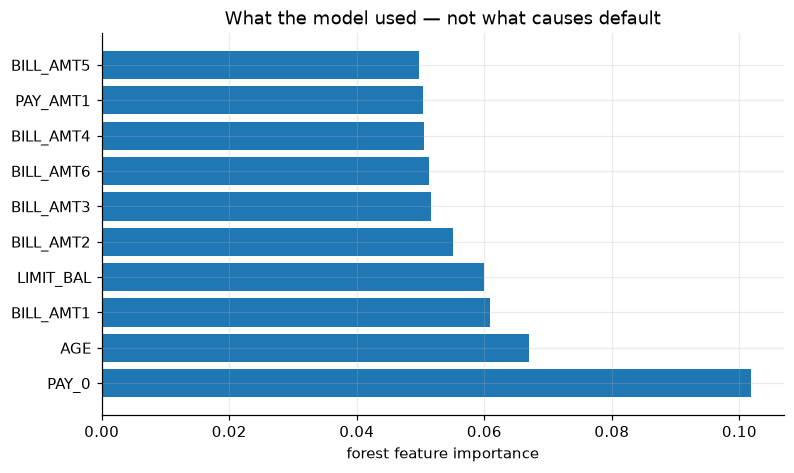

BILL_AMT1 importance: 0.0608
BILL_AMT2 importance: 0.0551
correlation between the two columns: 0.9515
all six BILL_AMT columns together: 0.3191 of the total 1.0

BILL_AMT1 beside its five near-copies: 0.0608  (rank 3)
BILL_AMT1 with the copies dropped:    0.0986  (rank 2)


In [13]:
# ────────────────────────────────────────────────────────────────────
# 1) Fit the 200-tree forest on all the rows, then read feature_importances_.
#    Pair it with FEATURES and sort, descending.
# 2) Plot the top ten as a horizontal bar chart, largest at the top.
# 3) Print the importance of BILL_AMT1 and BILL_AMT2 side by side, with the
#    correlation between the two columns next to them.
# Search: "sklearn feature_importances_ barh"
# https://scikit-learn.org/stable/modules/ensemble.html#feature-importance-evaluation
#
# ١) درّب الغابة ذات المئتي شجرة على الصفوف كلها ثم اقرأ `feature_importances_`.
#    وازدواجها مع `FEATURES` ورتّبها تنازليًا.
# ٢) ارسم أعلى عشرة كمخطّط أعمدة أفقي، والأكبر في الأعلى.
# ٣) اطبع أهمية `BILL_AMT1` و`BILL_AMT2` جنبًا إلى جنب، وبجانبهما الارتباط بين
#    العمودين.
# ابحث عن: "sklearn feature_importances_ barh"
# ────────────────────────────────────────────────────────────────────

forest = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
forest.fit(X, y)
# TODO: Build a Series of importances indexed by feature name, sorted descending.
# مهمة: ابنِ `Series` من الأهمّيات مُفهرسًا بأسماء الخصائص ومرتّبًا تنازليًا.

importances = pd.Series(
    forest.feature_importances_,
    index=FEATURES,
).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
# TODO: Plot the top ten importances as horizontal bars, largest at the top.
# مهمة: ارسم أعلى عشر أهمّيات كأعمدة أفقية، والأكبر في الأعلى.

top_importances = importances.head(10).sort_values()
ax.barh(top_importances.index, top_importances.values)
ax.invert_yaxis()
ax.set_xlabel("forest feature importance")
ax.set_title("What the model used — not what causes default")
plt.show()
pair_corr = df["BILL_AMT1"].corr(df["BILL_AMT2"])
print(f"BILL_AMT1 importance: {importances['BILL_AMT1']:.4f}")
print(f"BILL_AMT2 importance: {importances['BILL_AMT2']:.4f}")
print(f"correlation between the two columns: {pair_corr:.4f}")
bill_columns = [c for c in FEATURES if c.startswith("BILL_AMT")]
print(f"all six BILL_AMT columns together: "
      f"{importances[bill_columns].sum():.4f} of the total 1.0")
# TODO: Now take the copies away: refit the same forest with BILL_AMT2..6 dropped, and print what BILL_AMT1's importance becomes when it is the only bill column.
# مهمة: أزِل النسخ الآن: أعِد تدريب الغابة نفسها بعد حذف `BILL_AMT2` إلى `BILL_AMT6`، واطبع ما تصير إليه أهمية `BILL_AMT1` وهو عمود الفاتورة الوحيد.

solo_features = [
    c for c in FEATURES
    if c == "BILL_AMT1" or not c.startswith("BILL_AMT")
]
solo_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
solo_forest.fit(X[solo_features], y)
solo_importances = pd.Series(
    solo_forest.feature_importances_,
    index=solo_features,
).sort_values(ascending=False)
print(f"\nBILL_AMT1 beside its five near-copies: "
      f"{importances['BILL_AMT1']:.4f}  (rank "
      f"{int(importances.rank(ascending=False)['BILL_AMT1'])})")
print(f"BILL_AMT1 with the copies dropped:    "
      f"{solo_importances['BILL_AMT1']:.4f}  (rank "
      f"{int(solo_importances.rank(ascending=False)['BILL_AMT1'])})")

Three numbers, and they say the same thing three ways.

`BILL_AMT1` scores **0.0612** sitting beside five near-copies of itself, and **0.0984** — 60% more —
when they are dropped. Its rank moves from third to second. Nothing about the client's debt changed
between those two fits; the only difference is how many columns were available to take the credit
for it.

The six `BILL_AMT` columns together hold **0.3193** — a third of the entire chart — for what is
substantially **one** fact about a client, recorded six times. Each copy takes a share, and each
share looks modest.

So the ranking is a fact about how the model divided credit among the columns it was given. It is
not a fact about the client, and it is not a fact about your business. Report it as "the model relied
on this", never as "this drives default".

<div dir="rtl" align="right">

ثلاثة أرقام، وتقول الشيء نفسه بثلاث طرق.

يسجّل `BILL_AMT1` قيمة **٠٫٠٦١٢** وهو جالس بجانب خمس نسخ شبه متطابقة منه، و**٠٫٠٩٨٤** — أي أكثر بـ
٦٠٪ — عند حذفها. وينتقل ترتيبه من الثالث إلى الثاني. ولم يتغيّر شيء في دَين العميل بين التدريبين؛
والفرق الوحيد هو عدد الأعمدة المتاحة لتنسب الفضل إلى نفسها.

وأعمدة `BILL_AMT` الستة تحمل مجتمعةً **٠٫٣١٩٣** — ثلث المخطّط كله — مقابل ما هو في جوهره حقيقة
**واحدة** عن العميل، مسجّلة ست مرات. فكل نسخة تأخذ حصة، وكل حصة تبدو متواضعة.

فالترتيب حقيقة عن كيف قسّم النموذج الفضل بين الأعمدة التي أُعطيها. وليس حقيقة عن العميل ولا عن عملك.
اعرضه بصيغة «اعتمد النموذج على هذا»، لا بصيغة «هذا يسبّب التعثّر».

</div>


**Your sentence:** _(why is this ranking not a ranking of what matters?)_

<div dir="rtl" align="right">

**جملتك:** _(لماذا ليس هذا الترتيب ترتيبًا لما يهمّ؟)_

</div>


### Task 2.6 — scale it, and confirm nothing happens

W2D4 promised you this and today you check it. A tree splits on thresholds, and scaling maps every
threshold onto a new number **in the same order**. Same order means the same rows land on the same
side of every split, which means the same partition, which means the same tree.

Fit the forest on `StandardScaler`-transformed features and compare the two AUCs to four decimals.
Then write the sentence that explains it — one line, in the markdown cell below.

<div dir="rtl" align="right">

### المهمة ٢٫٦ — قيِّسها وتحقّق أن لا شيء يحدث

وعدك الأسبوع الثاني اليوم الرابع بهذا، واليوم تتحقّق منه. فالشجرة تقسّم على عتبات، والتقييس ينقل كل
عتبة إلى رقم جديد **بالترتيب نفسه**. والترتيب نفسه يعني أن الصفوف نفسها تقع في الجهة نفسها من كل
تقسيم، وهذا يعني التقسيم نفسه، وهذا يعني الشجرة نفسها.

درّب الغابة على خصائص محوّلة بـ `StandardScaler` وقارن المساحتين تحت المنحنى إلى أربع خانات عشرية.
ثم اكتب الجملة التي تفسّر ذلك — سطر واحد في خليّة النصّ أدناه.

</div>


In [14]:
# ────────────────────────────────────────────────────────────────────
# 1) Wrap a StandardScaler and the same forest in one pipeline, so the scaler is
#    refitted per fold and you are not leaking (W2D5's habit, and it still applies
#    even when the answer is that it changes nothing).
# 2) Score it on the same folds with the same scoring, and compare with the
#    unscaled forest_scores you already have.
# 3) Print the difference. np.isclose, not ==, for the comparison.
# Search: "sklearn make_pipeline StandardScaler RandomForestClassifier"
# https://scikit-learn.org/stable/modules/preprocessing.html
#
# ١) لُفَّ `StandardScaler` والغابة نفسها في خطّ معالجة واحد، فيُعاد تدريب المُقيِّس
#    في كل طيّة ولا تُسرِّب (وهي عادة الأسبوع الثاني اليوم الخامس، وتبقى سارية حتى
#    حين يكون الجواب أنها لا تغيّر شيئًا).
# ٢) قِسه على الطيّات نفسها وبالمقياس نفسه وقارنه بـ `forest_scores` غير المُقيَّس
#    الذي عندك.
# ٣) اطبع الفرق، واستخدم `np.isclose` لا `==` في المقارنة.
# ابحث عن: "sklearn make_pipeline StandardScaler RandomForestClassifier"
# ────────────────────────────────────────────────────────────────────

# TODO: Cross-validate the forest with a StandardScaler in front of it.
# مهمة: طبّق التحقّق المتقاطع على الغابة مع `StandardScaler` أمامها.

scaled_forest = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
)
scaled_scores = cv_auc(scaled_forest, "scaled random forest")
# TODO: Then the exact version: one tree, fitted on X and on scaled X, and compare its predictions row by row. This one is not "close" — it is identical.
# مهمة: ثم النسخة القاطعة: شجرة واحدة مُدرَّبة على `X` وعلى `X` المُقيَّس، وقارن تنبّؤاتها صفًا بصف. وهذه ليست «قريبة» بل مطابقة.

tree_unscaled = DecisionTreeClassifier(random_state=42).fit(X, y)
X_scaled = StandardScaler().fit_transform(X)
tree_scaled = DecisionTreeClassifier(random_state=42).fit(X_scaled, y)

same_structure = (
    tree_unscaled.tree_.node_count == tree_scaled.tree_.node_count
    and np.array_equal(tree_unscaled.tree_.feature, tree_scaled.tree_.feature)
    and np.array_equal(
        tree_unscaled.tree_.children_left,
        tree_scaled.tree_.children_left,
    )
    and np.array_equal(
        tree_unscaled.tree_.children_right,
        tree_scaled.tree_.children_right,
    )
)

same_predictions = np.array_equal(
    tree_unscaled.predict(X),
    tree_scaled.predict(X_scaled),
)
print(f"unscaled forest: {forest_scores.mean():.6f}")
print(f"scaled forest:   {scaled_scores.mean():.6f}")
print(f"rounded to 4 decimals: {forest_scores.mean():.4f} and "
      f"{scaled_scores.mean():.4f}")
print(f"difference:      {abs(forest_scores.mean() - scaled_scores.mean()):.2e}")
print(f"\none unpruned tree, scaled vs unscaled:")
print(f"  same split columns, node for node: {same_structure}")
print(f"  same prediction on all {len(X):,} rows: {same_predictions}")

scaled random forest               0.7654 +/- 0.0039
unscaled forest: 0.765534
scaled forest:   0.765378
rounded to 4 decimals: 0.7655 and 0.7654
difference:      1.55e-04

one unpruned tree, scaled vs unscaled:
  same split columns, node for node: True
  same prediction on all 30,000 rows: True


Read both halves of that output, because they say different things.

**The single tree is identical.** Same split column at every node, and the same prediction on all
30,000 rows. Not approximately — exactly. That is the claim W2D4 made: scaling maps every threshold
to a new number in the same order, so the same rows land on the same side of every split.

**The forest differs by 0.00016 of AUC.** That is not scaling doing something; it is floating-point
arithmetic. `StandardScaler` divides by a standard deviation, and a handful of the forest's thousands
of near-tied thresholds break the other way afterwards. It is small enough to disappear at the third
decimal — 0.766 either way — but read the printout rather than this sentence: at four decimals the
two are 0.7656 and 0.7655, and they already disagree.

Which is worth noticing in its own right. A wobble of 0.00016 that you did nothing to cause is what
*computation* looks like, and it lands in the fourth decimal place — the same place people quote
improvements. If someone shows you a 0.0002 gain and calls it a result, this is the size of the noise
floor they are standing on.

<div dir="rtl" align="right">

اقرأ نصفَي المخرَج، فكل نصف يقول شيئًا مختلفًا.

**الشجرة الواحدة مطابقة.** عمود التقسيم نفسه في كل عقدة، والتنبّؤ نفسه على الثلاثين ألف صف كلها. لا
تقريبًا بل تمامًا. وهذا هو ما وعد به الأسبوع الثاني اليوم الرابع: التقييس ينقل كل عتبة إلى رقم جديد
بالترتيب نفسه، فتقع الصفوف نفسها في الجهة نفسها من كل تقسيم.

**والغابة تختلف بمقدار ٠٫٠٠٠١٦ من المساحة تحت المنحنى.** وهذا ليس فعل التقييس، بل حساب الفواصل
العائمة. فـ `StandardScaler` يقسّم على انحراف معياري، فينكسر بعد ذلك عدد قليل من عتبات الغابة
المتعادلة تقريبًا في الجهة الأخرى. وهو صغير يختفي عند الخانة الثالثة — ٠٫٧٦٦ في الحالتين — لكن اقرأ
المخرَج لا هذه الجملة: عند أربع خانات يكون الرقمان ٠٫٧٦٥٦ و٠٫٧٦٥٥، وقد اختلفا فعلًا.

وهذا جديرٌ بالملاحظة بذاته. فتذبذب مقداره ٠٫٠٠٠١٦ لم تفعل شيئًا لتُحدثه هو شكل **الحساب**، وهو يقع في
الخانة العشرية الرابعة، أي الخانة نفسها التي يذكر الناس فيها تحسّناتهم. فإن أراك أحدهم مكسبًا مقداره
٠٫٠٠٠٢ وسمّاه نتيجة، فهذا هو حجم أرضية الضوضاء التي يقف عليها.

</div>


**Your sentence:** _(why did scaling change nothing, and what would have changed if this had been a
logistic regression?)_

<div dir="rtl" align="right">

**جملتك:** _(لماذا لم يغيّر التقييس شيئًا، وما الذي كان سيتغيّر لو كان هذا انحدارًا لوجستيًا؟)_

</div>


## Section 3 — Stretch: two importance charts that disagree  (≈30 min)

Open-ended. Lower expectation of completeness — this is where homework comes from.

The chart in task 2.5 is the forest's **built-in** importance: how much each column reduced impurity
across all 200 trees, measured on the rows the trees were fitted on. It has a known bias — it
inflates high-cardinality columns, because a column with thousands of distinct values gets thousands
of chances to look useful.

`permutation_importance` asks a different and more honest question: shuffle this one column in the
**validation** rows, refit nothing, and see how much the score drops. A column the model genuinely
depends on will hurt when you scramble it.

Compute both, put them side by side, and answer the question in the markdown cell after: **which one
goes in the report, and why?** Your capstone will ask you this in writing.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: مخطّطا أهمية يختلفان (نحو ٣٠ دقيقة)

مفتوح. والتوقّع في الإكمال أقل — ومن هنا يأتي العمل المنزلي.

المخطّط في المهمة ٢٫٥ هو الأهمية **المدمجة** في الغابة: كم خفّض كل عمود الشوائب في الأشجار المئتين
كلها، مقيسًا على الصفوف التي تدرّبت عليها الأشجار. وله تحيّز معروف: يُضخّم الأعمدة كثيرة القيم، لأن
العمود ذا آلاف القيم المختلفة يحصل على آلاف الفرص ليبدو مفيدًا.

أما `permutation_importance` فيسأل سؤالًا مختلفًا وأصدق: اخلط هذا العمود وحده في صفوف **التحقّق**،
ولا تُعِد تدريب شيء، وانظر كم تهبط النتيجة. فالعمود الذي يعتمد عليه النموذج فعلًا سيؤلم حين تخلطه.

احسب الاثنين وضعهما جنبًا إلى جنب، وأجب عن السؤال في خليّة النصّ بعدها: **أيّهما يدخل التقرير،
ولماذا؟** ومشروع تخرّجك سيسألك هذا كتابةً.

</div>


In [15]:
# ────────────────────────────────────────────────────────────────────
# 1) permutation_importance lives in sklearn.inspection. It needs a FITTED model
#    and the rows to permute — use the validation split, not the training rows,
#    or you are asking the same biased question again.
# 2) n_repeats=5 and the same scoring as everywhere else. It takes about a minute.
# 3) Put the two rankings in one DataFrame, keyed by feature, and print the ten
#    columns where they disagree most.
# Search: "sklearn permutation_importance validation set"
# https://scikit-learn.org/stable/modules/permutation_importance.html
#
# ١) يوجد `permutation_importance` في `sklearn.inspection`، ويحتاج نموذجًا
#    **مُدرَّبًا** والصفوف التي ستُخلط — استخدم قسم التحقّق لا صفوف التدريب، وإلا
#    فأنت تسأل السؤال المتحيّز نفسه مرة أخرى.
# ٢) `n_repeats=5` والمقياس نفسه المستخدم في كل مكان. تستغرق نحو دقيقة.
# ٣) ضع الترتيبين في `DataFrame` واحد مُفهرس بالخاصية، واطبع الأعمدة العشرة التي
#    يختلفان عليها أكثر ما يكون.
# ابحث عن: "sklearn permutation_importance validation set"
# ────────────────────────────────────────────────────────────────────

from sklearn.inspection import permutation_importance
forest_val = RandomForestClassifier(n_estimators=200, random_state=42,
                                    n_jobs=-1).fit(X_train, y_train)
# TODO: Compute permutation importance on the validation rows, 5 repeats, AUC.
# مهمة: احسب أهمية الخلط على صفوف التحقّق، بخمس تكرارات، بالمساحة تحت المنحنى.

permutation_result = permutation_importance(
    forest_val,
    X_val,
    y_val,
    n_repeats=5,
    scoring=SCORING,
    random_state=42,
    n_jobs=-1,
)
permutation_scores = pd.Series(
    permutation_result.importances_mean,
    index=FEATURES,
)
# TODO: Compare the two rankings in one table and print the biggest disagreements.
# مهمة: قارن الترتيبين في جدول واحد واطبع أكبر الخلافات.

both = pd.DataFrame({
    "builtin": importances,
    "permutation": permutation_scores,
})
both["builtin_rank"] = both["builtin"].rank(
    ascending=False,
    method="min",
)
both["permutation_rank"] = both["permutation"].rank(
    ascending=False,
    method="min",
)
both["rank_gap"] = (
    both["builtin_rank"] - both["permutation_rank"]
).abs()
disagreements = both.sort_values(
    ["rank_gap", "permutation"],
    ascending=[False, False],
)
print(disagreements.head(10).to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\ncolumns whose permutation importance is <= 0 "
      f"(shuffling them did not hurt at all): "
      f"{int((both['permutation'] <= 0).sum())} of {len(FEATURES)}")

           builtin  permutation  builtin_rank  permutation_rank  rank_gap
BILL_AMT6   0.0513      -0.0041        7.0000           23.0000   16.0000
BILL_AMT2   0.0551      -0.0016        5.0000           19.0000   14.0000
PAY_2       0.0394       0.0116       16.0000            3.0000   13.0000
PAY_3       0.0236       0.0053       18.0000            5.0000   13.0000
BILL_AMT3   0.0517      -0.0016        6.0000           18.0000   12.0000
BILL_AMT4   0.0505      -0.0017        8.0000           20.0000   12.0000
MARRIAGE    0.0139       0.0015       22.0000           11.0000   11.0000
BILL_AMT5   0.0497      -0.0025       10.0000           21.0000   11.0000
SEX         0.0122       0.0004       23.0000           15.0000    8.0000
PAY_AMT5    0.0435      -0.0032       14.0000           22.0000    8.0000

columns whose permutation importance is <= 0 (shuffling them did not hurt at all): 7 of 23


**Your two sentences:** _(which chart goes in the report, and what would you say to a stakeholder who
had already seen the other one?)_

<div dir="rtl" align="right">

**جملتاك:** _(أيّ المخطّطين يدخل التقرير، وماذا تقول لصاحب قرار رأى المخطّط الآخر أصلًا؟)_

</div>


## Save your artefact

`tree_baseline.json` — the best model of the day, its cross-validated mean **and** its standard
deviation, the feature ranking, and the full comparison table.

The standard deviation is not decoration. On Sunday you compare your neural network against this
number, and a comparison of two means with no spreads cannot tell you whether the difference is
real. W3D5 loads this file and reads both fields.

<div dir="rtl" align="right">

## احفظ مخرجاتك

`tree_baseline.json` وفيه أفضل نموذج في اليوم، ومتوسطه بالتحقّق المتقاطع **وانحرافه المعياري**،
وترتيب الخصائص، وجدول المقارنة كاملًا.

والانحراف المعياري ليس زينة. فيوم الأحد تقارن شبكتك العصبية بهذا الرقم، ومقارنة متوسطين بلا مدى
تفاوت لا تستطيع أن تخبرك هل الفرق حقيقي. ويُحمّل اليوم الخامس هذا الملف ويقرأ الحقلين معًا.

</div>


In [16]:
baseline = {
    "dataset": "credit_default",
    "metric": "roc_auc",
    "cv": "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)",
    "best_model": comparison.iloc[0]["model"],
    "best_params": {"learning_rate": float(best_boost["learning_rate"]),
                    "n_estimators": int(best_boost["n_estimators"])},
    "cv_mean": float(comparison.iloc[0]["auc_mean"]),
    "cv_std": float(comparison.iloc[0]["auc_std"]),
    "all_models": {row["model"]: {"cv_mean": float(row["auc_mean"]),
                                  "cv_std": float(row["auc_std"])}
                   for _, row in comparison.iterrows()},
    "feature_ranking": [{"feature": name, "importance": float(value)}
                        for name, value in importances.items()],
    "notes": ("Beat this on W3D5 with the neural network, or report that it was not beaten. "
              "The std is here so that comparison can be honest."),
}

out = ARTEFACT_DIR / "tree_baseline.json"
out.write_text(json.dumps(baseline, indent=2), encoding="utf-8")

reloaded = json.loads(out.read_text(encoding="utf-8"))
print(f"Saved {out}")
print(f"best model: {reloaded['best_model']}")
print(f"AUC {reloaded['cv_mean']:.4f} +/- {reloaded['cv_std']:.4f}")
print(f"top three features: "
      f"{[f['feature'] for f in reloaded['feature_ranking'][:3]]}")
print(f"models recorded: {len(reloaded['all_models'])}")

Saved c:\Users\حمزة\AIEP_Olo_student\week_3_neural_networks\labs\D1_trees_ensembles\artefacts\tree_baseline.json
best model: GradientBoostingClassifier (best grid)
AUC 0.7812 +/- 0.0054
top three features: ['PAY_0', 'AGE', 'BILL_AMT1']
models recorded: 5


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

The second one is the strangest in the notebook: it passes when your tree has **successfully
overfitted**. If it fails, your unlimited tree did not memorise the training set, and you should find
out why before believing the depth curve.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخليّة أخيرًا. كل فحص يفشل يخبرك بما تُصلحه ولماذا.

والفحص الثاني أغرب ما في الدفتر: فهو ينجح عندما **تُفرِط شجرتك في المطابقة بنجاح**. فإن فشل فشجرتك
بلا حدّ لم تحفظ بيانات التدريب، وعليك أن تعرف السبب قبل أن تصدّق منحنى العمق.

</div>


In [17]:
# --- Sanity checks ----------------------------------------------------------------

check(np.isclose(CHOSEN_GINI, 0.1875) and np.isclose(CHARGE_THRESHOLD, 83.0),
      f"the depth-1 tree must find a split as good as the room's — weighted Gini 0.1875, "
      f"got {CHOSEN_GINI:.4f} — and restricted to monthly_charge it must choose 83.0, the "
      f"midpoint of 78 and 88, not {CHARGE_THRESHOLD:.2f}",
      f"يجب أن تجد شجرة العمق ١ تقسيمًا بجودة تقسيم القاعة — قيمة Gini الموزونة ٠٫١٨٧٥ "
      f"والقيمة الحالية {CHOSEN_GINI:.4f} — وحين تُقيَّد بـ `monthly_charge` يجب أن تختار "
      f"٨٣٫٠ وهي منتصف ٧٨ و٨٨، لا {CHARGE_THRESHOLD:.2f}")

unpruned = depth_curve.iloc[-1]
check(unpruned["train"] > 0.99 and unpruned["gap"] > 0.05,
      f"the unlimited tree must memorise the training rows (train > 0.99, got "
      f"{unpruned['train']:.4f}) and lose at least 5 points on validation (gap "
      f"{unpruned['gap']:.4f}) — passing this means you produced overfitting on purpose",
      f"يجب أن تحفظ الشجرة بلا حدّ صفوف التدريب (تدريب > ٠٫٩٩، والقيمة "
      f"{unpruned['train']:.4f}) وأن تخسر ٥ نقاط على الأقل في التحقّق (الفجوة "
      f"{unpruned['gap']:.4f}) — والنجاح هنا يعني أنك أنتجت فرط المطابقة عن قصد")

check(forest_scores.mean() > tree_scores.mean(),
      f"the forest should beat the best single tree on AUC "
      f"({forest_scores.mean():.4f} vs {tree_scores.mean():.4f})",
      f"يجب أن تتجاوز الغابة أفضل شجرة واحدة في المساحة تحت المنحنى "
      f"({forest_scores.mean():.4f} مقابل {tree_scores.mean():.4f})")

check(forest_scores.std() < no_column_randomness.std(),
      f"removing the column randomness should widen the spread — the randomised forest's "
      f"std is {forest_scores.std():.4f} and the all-columns forest's is "
      f"{no_column_randomness.std():.4f}; if the second is not larger, check that you "
      f"passed max_features=1.0",
      f"يجب أن تُوسّع إزالة عشوائية الأعمدة مدى التفاوت — فانحراف الغابة المُعشّاة "
      f"{forest_scores.std():.4f} وانحراف غابة كل الأعمدة {no_column_randomness.std():.4f}؛ "
      f"وإن لم يكن الثاني أكبر فتحقّق أنك مرّرت `max_features=1.0`")

check(same_structure and same_predictions
      and abs(forest_scores.mean() - scaled_scores.mean()) < 1e-3,
      f"scaling must not change a tree: same structure {same_structure}, same predictions "
      f"{same_predictions}, and the forest's AUC must move by less than 0.001 (it moved "
      f"{abs(forest_scores.mean() - scaled_scores.mean()):.2e})",
      f"يجب ألا يغيّر التقييس الشجرة: البنية نفسها {same_structure}، والتنبّؤات نفسها "
      f"{same_predictions}، وعلى مساحة الغابة تحت المنحنى أن تتحرّك أقل من ٠٫٠٠١ (تحرّكت "
      f"{abs(forest_scores.mean() - scaled_scores.mean()):.2e})")

check(len(comparison) == 5 and comparison["auc_mean"].max() > W1D4_LOGREG_AUC,
      f"the comparison table needs all five models ({len(comparison)} present) and its "
      f"winner must beat W1D4's logistic regression "
      f"({comparison['auc_mean'].max():.4f} vs {W1D4_LOGREG_AUC:.4f})",
      f"يحتاج جدول المقارنة النماذج الخمسة كلها (الموجود {len(comparison)}) وعلى فائزه أن "
      f"يتجاوز الانحدار اللوجستي من الأسبوع الأول اليوم الرابع "
      f"({comparison['auc_mean'].max():.4f} مقابل {W1D4_LOGREG_AUC:.4f})")

check(out.exists() and reloaded["cv_std"] > 0,
      f"tree_baseline.json must exist and record a spread, not just a mean "
      f"(std {reloaded['cv_std']:.4f})",
      f"يجب أن يوجد `tree_baseline.json` وأن يسجّل مدى تفاوت لا متوسطًا فقط "
      f"(الانحراف {reloaded['cv_std']:.4f})")

report()

──────────────────────────────────────────────────────────────────
  ✓  the depth-1 tree must find a split as good as the room's — weighted Gini 0.1875, got 0.1875 — and restricted to monthly_charge it must choose 83.0, the midpoint of 78 and 88, not 83.00
  ✓  the unlimited tree must memorise the training rows (train > 0.99, got 0.9995) and lose at least 5 points on validation (gap 0.2850) — passing this means you produced overfitting on purpose
  ✓  the forest should beat the best single tree on AUC (0.7655 vs 0.7548)
  ✓  removing the column randomness should widen the spread — the randomised forest's std is 0.0037 and the all-columns forest's is 0.0073; if the second is not larger, check that you passed max_features=1.0
  ✓  scaling must not change a tree: same structure True, same predictions True, and the forest's AUC must move by less than 0.001 (it moved 1.55e-04)
  ✓  the comparison table needs all five models (5 present) and its winner must beat W1D4's logistic regression (0.

## What's next

You have a number, a spread and a file, and the file is the point of the day.

Tomorrow (**W3D2**) the model changes completely: two inputs, two hidden neurons, one output, and you
compute its output by hand before you write a line of code. There is no training tomorrow — just the
machine, and the exact numbers from the morning slide (`[2.5, 1.0]` and `0.8176`).

Three things travel with you:

- **`tree_baseline.json`** — 0.7812 ± 0.0054. W3D5 loads it and puts your network beside it.
- **The 0.058 gap** between the linear model and the boosted one. Keep it in mind when you are
  tempted to describe a 0.01 improvement as a breakthrough.
- **For most capstone datasets — anything that arrives as a table of named columns — this is the
  model that will win.** Say so in your report, and put the tree in it.

<div dir="rtl" align="right">

## ماذا بعد

عندك رقم ومدى تفاوت وملف، والملف هو مقصود اليوم.

وغدًا (**الأسبوع ٣ اليوم ٢**) يتغيّر النموذج تمامًا: مدخلان وعصبونان مخفيان ومَخرج واحد، وتحسب مُخرَجه
بيدك قبل أن تكتب سطر شيفرة. ولا تدريب غدًا — الآلة وحدها، والأرقام بالضبط من شريحة الصباح
(`[2.5, 1.0]` و`0.8176`).

وثلاثة أمور تسافر معك:

- **`tree_baseline.json`** — ٠٫٧٨١٢ ± ٠٫٠٠٥٤. ويُحمّله اليوم الخامس ويضع شبكتك بجانبه.
- **فجوة الـ ٠٫٠٥٨** بين النموذج الخطي ونموذج التعزيز. تذكّرها حين تُغريك فكرة وصف تحسّن مقداره
  ٠٫٠١ بأنه اختراق.
- **ولأكثر بيانات مشاريع التخرّج — أي شيء يصل كجدول أعمدة مُسمّاة — هذا هو النموذج الذي سيفوز.**
  قُل ذلك في تقريرك، وضَع الشجرة فيه.

</div>
